# Simulasi Pengangkutan Sampah Desa
## Tugas Besar – Dasar Kecerdasan Artificial

**Algoritma Heuristik yang digunakan:**
- **Gerobak**: *Nearest Neighbor Heuristic* — selalu menuju rumah terdekat yang belum diambil  
- **Truk**: *Greedy Capacity Fill* — mengisi kapasitas dengan rumah-rumah terdekat per batch  
- **Transfer Gerobak→Truk**: *Cost-Benefit Analysis* — hitung waktu transfer vs pergi ke TPS  
- **Sharing sampah**: Satu rumah bisa diambil sebagian oleh beberapa gerobak/truk

In [116]:
import random
import math
from dataclasses import dataclass
from typing import List, Optional, Tuple

# CONST
# SEED = 42

NUM_HOUSES = 100
GRID_SIZE = 50 # grid 50x50 satuan
NUM_TPS = 3

CAP_GEROBAK = 15 # kg
CAP_TRUK = 200 # kg
TPS_CAP_MIN = 400
TPS_CAP_MAX = 500

HOUSE_TRASH_MIN = 0
HOUSE_TRASH_MAX = 7

# Waktu operasi (menit sejak 00:00)
GEROBAK_START = 6 * 60 # 06:00
GEROBAK_END = 15 * 60 # 15:00
TRUK_START = 8 * 60 # 08:00
TRUK_END = 17 * 60 # 17:00

# Loading time
GEROBAK_LOAD_PER_KG = 2 # 2 menit/kg
TRUK_LOAD_PER_10KG = 2 # 2 menit per 10 kg

# Travel time
GEROBAK_TRAVEL_PER_DIST = 3 # 3 menit per 1 satuan jarak
TRUK_TRAVEL_PER_5DIST = 3 # 3 menit per 5 satuan jarak

print("Const ready")

Const ready


## Helper Func

In [117]:
# Konversi menit sejak 00:00 ke format HH:MM
def mins_to_hhmm(m: int) -> str:
    h = m // 60
    mn = m % 60
    return f"{h:02d}:{mn:02d}"

# Jarak Euclidean antara dua titik
def euclidean(a, b) -> float:
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Waktu tempuh gerobak: 3 menit per 1 satuan jarak
def gerobak_travel_time(dist: float) -> float:
    return dist * GEROBAK_TRAVEL_PER_DIST

# Waktu tempuh truk: 3 menit per 5 satuan jarak = 0.6 menit/satuan
def truk_travel_time(dist: float) -> float:
    return dist * (TRUK_TRAVEL_PER_5DIST / 5.0)

# Waktu loading gerobak: 2 menit per kg
def gerobak_load_time(kg: float) -> float:
    return kg * GEROBAK_LOAD_PER_KG

# Waktu loading truk: 2 menit per 10 kg
def truk_load_time(kg: float) -> float:
    return (kg / 10.0) * TRUK_LOAD_PER_10KG

print("Helper functions ready")

Helper functions ready


## Data Classes (House, TPS, LogEntry)

In [118]:
@dataclass
class House:
    id: int
    x: float
    y: float
    trash_initial: float
    trash_remaining: float = 0.0

    def __post_init__(self):
        self.trash_remaining = self.trash_initial


@dataclass
class TPS:
    id: int
    x: float
    y: float
    capacity: float
    stored: float = 0.0

    @property
    def available(self):
        return self.capacity - self.stored


@dataclass
class LogEntry:
    actor: str
    time: str
    event: str
    detail: str

    def __str__(self):
        return f"[{self.time}] {self.actor:<12} | {self.event:<20} | {self.detail}"

print("Data classes ready")

Data classes ready


## Agent Classes (Gerobak & Truk)

In [119]:
# Agen gerobak sampah
# Heuristik: Nearest Neighbor — selalu menuju rumah terdekat yang ada sampah
# Bisa transfer sampah ke truk jika lebih efisien daripada ke TPS
class Gerobak:
    def __init__(self, gid: int, start_pos: Tuple[float, float]):
        self.id = gid
        self.x, self.y = start_pos
        self.load = 0.0
        self.time = GEROBAK_START
        self.total_dist = 0.0
        self.total_time_travel = 0.0
        self.total_time_load = 0.0
        self.logs: List[LogEntry] = []
        self.active = True
        self.trips_to_tps = 0
        self.trips_to_truk = 0

    @property
    def pos(self): return (self.x, self.y)

    def name(self): return f"Gerobak-{self.id}"

    def log(self, event: str, detail: str):
        self.logs.append(LogEntry(
            actor=self.name(),
            time=mins_to_hhmm(int(self.time)),
            event=event, detail=detail))

    def move_to(self, tx, ty):
        dist = euclidean(self.pos, (tx, ty))
        travel = gerobak_travel_time(dist)
        self.x, self.y = tx, ty
        self.total_dist += dist
        self.total_time_travel += travel
        self.time += travel
        return dist, travel

    # Ambil sampah dari rumah (bisa sebagian — sharing support)
    def collect_from_house(self, house: 'House', kg: float):
        load_t = gerobak_load_time(kg)
        house.trash_remaining = max(0.0, house.trash_remaining - kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.log("AMBIL_SAMPAH",
            f"Rumah-{house.id} ({house.x:.1f},{house.y:.1f}) "
            f"ambil {kg:.2f}kg | sisa rumah {house.trash_remaining:.2f}kg "
            f"| muatan gerobak {self.load:.2f}kg")

    # Buang semua muatan ke TPS
    def dump_to_tps(self, tps: 'TPS'):
        kg = self.load
        load_t = gerobak_load_time(kg)
        tps.stored = min(tps.capacity, tps.stored + kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("BUANG_TPS",
            f"TPS-{tps.id} ({tps.x:.1f},{tps.y:.1f}) "
            f"buang {kg:.2f}kg | TPS {tps.stored:.1f}/{tps.capacity:.1f}kg")
        self.load = 0.0
        self.trips_to_tps += 1

    # Titipkan sebagian/seluruh muatan ke truk saat berpapasan
    def dump_to_truck(self, truk: 'Truk', kg: float):
        load_t = gerobak_load_time(kg)
        self.load = max(0.0, self.load - kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("TITIP_TRUK",
            f"Transfer {kg:.2f}kg ke {truk.name()} | "
            f"sisa di gerobak {self.load:.2f}kg")
        self.trips_to_truk += 1

# Agen truk sampah.
# Heuristik: Greedy Capacity Fill — ambil batch rumah terdekat sampai hampir penuh.
# Mulai dari TPS dan kembali ke TPS saat penuh.
class Truk:
    def __init__(self, tid: int, tps: 'TPS'):
        self.id = tid
        self.x, self.y = tps.x, tps.y
        self.home_tps = tps
        self.load = 0.0
        self.time = TRUK_START
        self.total_dist = 0.0
        self.total_time_travel = 0.0
        self.total_time_load = 0.0
        self.logs: List[LogEntry] = []
        self.active = True
        self.trips_to_tps = 0
        self.received_from_gerobak_kg = 0.0 
        
    @property
    def pos(self): return (self.x, self.y)

    def name(self): return f"Truk-{self.id}"

    def log(self, event: str, detail: str):
        self.logs.append(LogEntry(
            actor=self.name(),
            time=mins_to_hhmm(int(self.time)),
            event=event, detail=detail))

    def move_to(self, tx, ty):
        dist = euclidean(self.pos, (tx, ty))
        travel = truk_travel_time(dist)
        self.x, self.y = tx, ty
        self.total_dist += dist
        self.total_time_travel += travel
        self.time += travel
        return dist, travel

    # Ambil sampah dari rumah
    def collect_from_house(self, house: 'House', kg: float):
        load_t = truk_load_time(kg)
        house.trash_remaining = max(0.0, house.trash_remaining - kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.log("AMBIL_SAMPAH",
            f"Rumah-{house.id} ({house.x:.1f},{house.y:.1f}) "
            f"ambil {kg:.2f}kg | sisa rumah {house.trash_remaining:.2f}kg "
            f"| muatan truk {self.load:.2f}kg")

    # Buang semua muatan ke TPS
    def dump_to_tps(self, tps: 'TPS'):
        kg = self.load
        load_t = truk_load_time(kg)
        tps.stored = min(tps.capacity, tps.stored + kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("BUANG_TPS",
            f"TPS-{tps.id} ({tps.x:.1f},{tps.y:.1f}) "
            f"buang {kg:.2f}kg | TPS {tps.stored:.1f}/{tps.capacity:.1f}kg")
        self.load = 0.0
        self.trips_to_tps += 1

    # Terima sampah dari gerobak saat berpapasan
    def receive_from_gerobak(self, gerobak: 'Gerobak', kg: float):
        load_t = truk_load_time(kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.received_from_gerobak_kg += kg  # Buat nyatet total transfer masuk ke truk dari gerobak
        self.log("TERIMA_GEROBAK",
            f"Terima {kg:.2f}kg dari {gerobak.name()} | "
            f"muatan truk {self.load:.2f}kg")

print("Agent classes ready")

Agent classes ready


## Func Generate Peta Desa

In [120]:
# Generate posisi rumah dan TPS secara acak
# Semua posisi (rumah maupun TPS) di-random di dalam grid
# Constraint: posisi TPS tidak boleh sama/bertumpuk dengan rumah
def generate_map():
    houses = []
    positions = set()

    # Generate posisi rumah secara random
    for i in range(NUM_HOUSES):
        while True:
            x = round(random.uniform(0, GRID_SIZE), 1)
            y = round(random.uniform(0, GRID_SIZE), 1)
            if (x, y) not in positions:
                positions.add((x, y))
                break
        trash = round(random.uniform(HOUSE_TRASH_MIN, HOUSE_TRASH_MAX), 2)
        houses.append(House(id=i+1, x=x, y=y, trash_initial=trash))

    # Generate posisi TPS secara random
    tps_list = []
    for i in range(NUM_TPS):
        while True:
            tx = round(random.uniform(0, GRID_SIZE), 1)
            ty = round(random.uniform(0, GRID_SIZE), 1)
            if (tx, ty) not in positions:
                positions.add((tx, ty))
                break
        cap = round(random.uniform(TPS_CAP_MIN, TPS_CAP_MAX), 1)
        tps_list.append(TPS(id=i+1, x=tx, y=ty, capacity=cap))

    return houses, tps_list

print("Func Generate Map Ready")

Func Generate Map Ready


## Inisialisasi Data

In [121]:
# random.seed()

# Jumlah agen
NUM_GEROBAK = random.randint(5, 7)
NUM_TRUK = random.randint(2, 4)

# Peta: rumah + TPS
houses, tps_list = generate_map()

# Truk mulai dari TPS
truk_list: List[Truk] = []
for i in range(NUM_TRUK):
    home_tps = tps_list[i % NUM_TPS]
    truk_list.append(Truk(i+1, home_tps))

# Gerobak mulai dari titik random
gerobak_list: List[Gerobak] = []
for i in range(NUM_GEROBAK):
    sx = round(random.uniform(2, GRID_SIZE - 2), 1)
    sy = round(random.uniform(2, GRID_SIZE - 2), 1)
    gerobak_list.append(Gerobak(i+1, (sx, sy)))

# Snapshot koordinat awal untuk verifikasi konsistensi
_snapshot_houses = {h.id: (h.x, h.y) for h in houses}
_snapshot_tps = {t.id: (t.x, t.y) for t in tps_list}
_snapshot_gerobak = {g.id: (g.x, g.y) for g in gerobak_list}

# Tampilkan ringkasan
total_trash = sum(h.trash_initial for h in houses)
# print(f"INISIALISASI DATA (SEED={SEED})")
print()
print(f"Jumlah gerobak: {NUM_GEROBAK}")
print(f"Jumlah truk: {NUM_TRUK}")
print(f"Jumlah TPS: {NUM_TPS}")
print(f"Jumlah rumah: {NUM_HOUSES}")
print(f"Total sampah: {total_trash:.2f} kg")
print(f"Rata-rata/rumah: {total_trash/NUM_HOUSES:.2f} kg")
print()
print("Lokasi TPS (random):")
for t in tps_list:
    print(f"TPS-{t.id}: ({t.x:.1f}, {t.y:.1f})  kap={t.capacity:.1f} kg")
print()
print("Posisi awal Gerobak (random):")
for g in gerobak_list:
    print(f"Gerobak-{g.id}: ({g.x:.1f}, {g.y:.1f})")
print()
print("Posisi awal Truk (dari TPS):")
for t in truk_list:
    print(f"Truk-{t.id}: ({t.x:.1f}, {t.y:.1f})  <- TPS-{t.home_tps.id}")


Jumlah gerobak: 7
Jumlah truk: 2
Jumlah TPS: 3
Jumlah rumah: 100
Total sampah: 382.99 kg
Rata-rata/rumah: 3.83 kg

Lokasi TPS (random):
TPS-1: (20.5, 17.1)  kap=455.8 kg
TPS-2: (4.3, 0.5)  kap=466.1 kg
TPS-3: (11.8, 17.5)  kap=499.6 kg

Posisi awal Gerobak (random):
Gerobak-1: (39.4, 22.9)
Gerobak-2: (18.8, 22.4)
Gerobak-3: (43.1, 6.9)
Gerobak-4: (17.1, 44.5)
Gerobak-5: (31.4, 25.2)
Gerobak-6: (22.9, 11.1)
Gerobak-7: (45.2, 4.2)

Posisi awal Truk (dari TPS):
Truk-1: (20.5, 17.1)  <- TPS-1
Truk-2: (4.3, 0.5)  <- TPS-2


### Visualisasi Peta Penduduk

Verifikasi: 100 rumah, 3 TPS
Rumah-1: (28.0, 0.6) sampah=5.84kg
TPS-1: (20.5, 17.1) kap=455.8kg

Koordinat terverifikasi ...


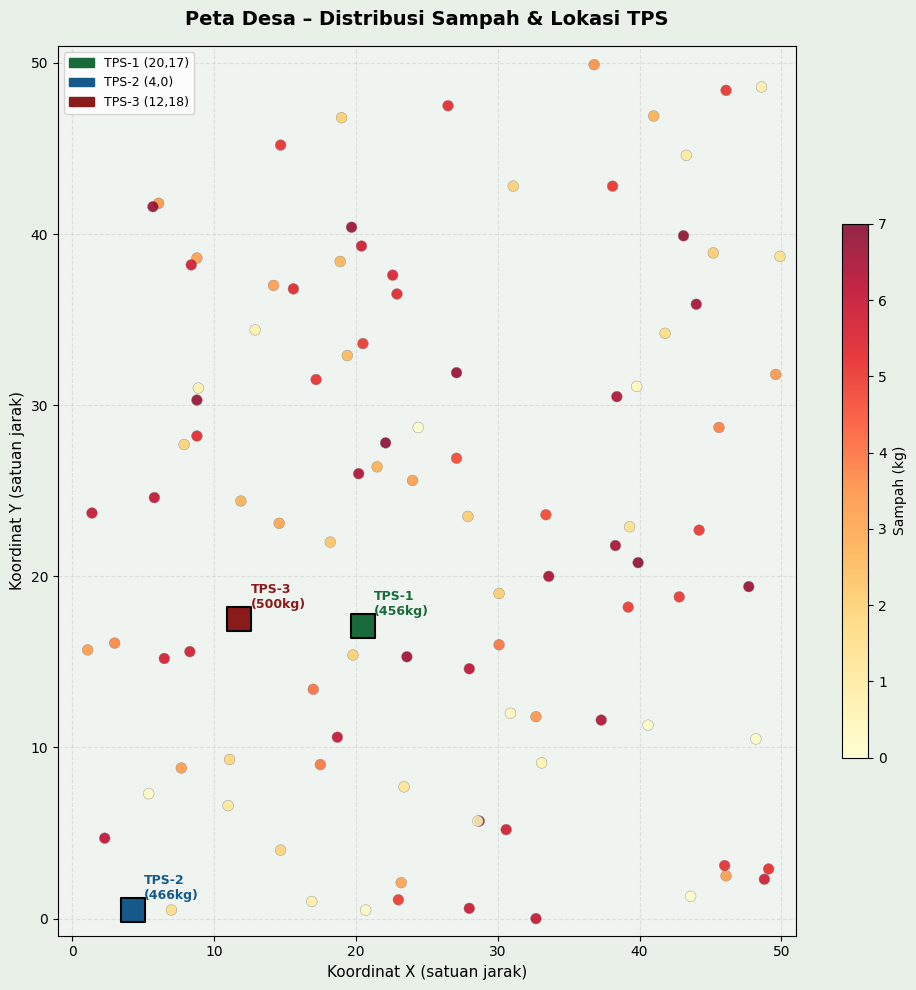

Peta saved


In [122]:
# Cek konsistensi koordinat
print(f"Verifikasi: {len(houses)} rumah, {len(tps_list)} TPS")
print(f"Rumah-1: ({houses[0].x:.1f}, {houses[0].y:.1f}) sampah={houses[0].trash_initial:.2f}kg")
print(f"TPS-1: ({tps_list[0].x:.1f}, {tps_list[0].y:.1f}) kap={tps_list[0].capacity:.1f}kg")
print()
assert all(_snapshot_houses[h.id] == (h.x, h.y) for h in houses), \
    "ERROR: Koordinat rumah berubah dari inisialisasi!"
assert all(_snapshot_tps[t.id] == (t.x, t.y) for t in tps_list), \
    "ERROR: Koordinat TPS berubah dari inisialisasi!"
print("Koordinat terverifikasi ...")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-1, GRID_SIZE+1)
ax.set_ylim(-1, GRID_SIZE+1)
ax.set_facecolor('#f0f4f0')
fig.patch.set_facecolor('#e8f0e8')

# Plot rumah berdasarkan jumlah sampah
trash_vals = [h.trash_initial for h in houses]
hx = [h.x for h in houses]
hy = [h.y for h in houses]
sc = ax.scatter(hx, hy, c=trash_vals, cmap='YlOrRd', s=60, alpha=0.85, zorder=3, vmin=0, vmax=HOUSE_TRASH_MAX, edgecolors='gray', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Sampah (kg)', shrink=0.6)

# Plot TPS
tps_colors = ['#1a6b3c', '#155a8a', '#8b1a1a']
tps_labels = []
for i, tps in enumerate(tps_list):
    ax.scatter(tps.x, tps.y, c=tps_colors[i], s=300, marker='s', zorder=5, edgecolors='black', linewidths=1.5)
    ax.annotate(f'TPS-{tps.id}\n({tps.capacity:.0f}kg)', (tps.x, tps.y), textcoords="offset points", xytext=(8, 8), fontsize=9, fontweight='bold', color=tps_colors[i])
    tps_labels.append(mpatches.Patch(color=tps_colors[i], label=f'TPS-{tps.id} ({tps.x:.0f},{tps.y:.0f})'))

ax.set_title('Peta Desa – Distribusi Sampah & Lokasi TPS', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Koordinat X (satuan jarak)', fontsize=11)
ax.set_ylabel('Koordinat Y (satuan jarak)', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(handles=tps_labels, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('peta_desa.png', dpi=120, bbox_inches='tight')
plt.show()
print("Peta saved")

## Fungsi Heuristik

In [123]:
# Temukan TPS terdekat yang masih ada kapasitas
def nearest_tps(pos: Tuple, tps_list: List[TPS]) -> Optional[TPS]:
    candidates = [t for t in tps_list if t.available > 0.5]
    if not candidates:
        return None
    return min(candidates, key=lambda t: euclidean(pos, (t.x, t.y)))

# Temukan rumah terdekat yang masih ada sampah
def nearest_house(pos: Tuple, houses: List[House]) -> Optional[House]:
    candidates = [h for h in houses if h.trash_remaining > 0.01]
    if not candidates:
        return None
    return min(candidates, key=lambda h: euclidean(pos, (h.x, h.y)))

# Heuristik cost-benefit: Bandingkan waktu yang dihabiskan jika gerobak mentransfer ke truk vs truk langsung ke TPS
# Return: ('transfer', time_saved) atau ('skip', 0)
def cost_benefit_transfer(gerobak: Gerobak, truk: Truk, tps_list: List[TPS]) -> Tuple[str, float]:
    # Tidak ada gunanya transfer jika truk hampir penuh
    if truk.load + gerobak.load > CAP_TRUK * 0.98:
        return ('skip', 0)
    # Tidak ada gunanya transfer jika gerobak kosong
    if gerobak.load < 1.0:
        return ('skip', 0)

    # Skenario A: Gerobak jalan ke truk dulu → transfer
    dist_g_to_t = euclidean(gerobak.pos, truk.pos)
    time_A = gerobak_travel_time(dist_g_to_t) + gerobak_load_time(gerobak.load)

    # Skenario B: Gerobak langsung ke TPS terdekat
    best_tps = nearest_tps(gerobak.pos, tps_list)
    if best_tps is None:
        return ('skip', 0)
    dist_g_to_tps = euclidean(gerobak.pos, (best_tps.x, best_tps.y))
    time_B = gerobak_travel_time(dist_g_to_tps) + gerobak_load_time(gerobak.load)

    # Transfer lebih untung jika: truk lebih dekat dari TPS, dan gerobak punya muatan signifikan
    if dist_g_to_t < dist_g_to_tps * 0.75 and gerobak.load >= 3.0:
        return ('transfer', time_B - time_A)
    return ('skip', 0)

# Greedy: rencanakan batch pengambilan untuk truk
# Pilih rumah-rumah terdekat sampai kapasitas terpenuhi
# Maksimum `max_houses` rumah per batch
def greedy_batch_plan(truk: Truk, houses: List[House], max_houses: int = 8) -> List[Tuple[House, float]]:
    plan = []
    remaining_cap = CAP_TRUK - truk.load
    current_pos = truk.pos
    visited_ids = set()

    while remaining_cap > 0.5 and len(plan) < max_houses:
        candidates = [h for h in houses if h.id not in visited_ids and h.trash_remaining > 0.01]
        if not candidates:
            break
        # Nearest neighbor dari posisi sekarang
        best = min(candidates, key=lambda h: euclidean(current_pos, (h.x, h.y)))
        take = min(best.trash_remaining, remaining_cap)
        plan.append((best, take))
        remaining_cap -= take
        current_pos = (best.x, best.y)
        visited_ids.add(best.id)

    return plan

print("Func heuristik ready")

Func heuristik ready


## Jalankan Simulasi

In [124]:
# ============================================================
# SIMULASI UTAMA — Concurrent Event-Driven // Concurent, bukan semi paralel !!!
# ============================================================
# Gerobak dan truk berjalan dalam SATU loop bersama.
# Setiap iterasi, agen dengan waktu (time) terkecil dipilih untuk
# melakukan satu langkah aksi berikutnya — mirip priority queue.
# Efeknya: truk mulai jam 08:00 bisa benar-benar "berpapasan"
# dengan gerobak yang sudah jalan sejak 06:00.
# Itu bagian jam yang nyetting kau lo yo :v
# ============================================================
print("Menjalankan simulasi concurrent (gerobak + truk) ...")

# Status selesai untuk tiap agen
gerobak_done = [False] * NUM_GEROBAK
truk_done    = [False] * NUM_TRUK
iteration = 0

while not (all(gerobak_done) and all(truk_done)):
    iteration += 1
    if iteration > 500_000:  # safety break ditingkatkan karena lebih banyak agen aktif bersamaan
        print("Safety break!")
        break

    # Kumpulkan semua agen yang belum selesai beserta indexnya
    active_gerobak = [(i, g) for i, g in enumerate(gerobak_list) if not gerobak_done[i]]
    active_truk    = [(i, t) for i, t in enumerate(truk_list)    if not truk_done[i]]

    # Gabungkan semua agen aktif — gerobak diberi tag 'g', truk diberi tag 't'
    candidates = [("g", i, a) for i, a in active_gerobak] + \
                 [("t", i, a) for i, a in active_truk]
    if not candidates:
        break

    # Pilih agen dengan waktu (time) terkecil — event-driven scheduling
    agent_type, idx, agent = min(candidates, key=lambda x: x[2].time)

    # ──────────────────────────────────────────────
    # AKSI GEROBAK
    # Heuristik: Nearest Neighbor — selalu ke rumah terdekat yang ada sampah
    # ──────────────────────────────────────────────
    if agent_type == "g":
        g = agent

        # Hard stop: waktu operasi gerobak habis (15:00)
        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU",
                  f"Operasi selesai {mins_to_hhmm(GEROBAK_END)} | "
                  f"sisa muatan {g.load:.2f}kg | jarak total {g.total_dist:.2f}")
            continue

        # Gerobak hampir penuh (≥90% kapasitas) → coba titip ke truk atau buang ke TPS
        if g.load >= CAP_GEROBAK * 0.9:

            # Cari truk aktif yang dekat dan masih bisa menerima.
            # Karena loop sekarang concurrent, posisi truk sudah REAL (bukan di TPS asal)
            best_truk = None
            best_dist = float('inf')
            for t in truk_list:
                if t.time >= TRUK_END:
                    continue  # truk ini sudah selesai operasi
                d = euclidean(g.pos, t.pos)
                can_accept = CAP_TRUK - t.load
                # Truk harus cukup dekat (< 12 satuan) dan masih punya ruang ≥ 5 kg
                if d < best_dist and can_accept >= 5.0 and d < 12:
                    best_dist = d
                    best_truk = t

            if best_truk:
                # Bandingkan: lebih dekat ke truk, atau ke TPS?
                tps_for_compare = nearest_tps(g.pos, tps_list)
                dist_tps = euclidean(g.pos, (tps_for_compare.x, tps_for_compare.y)) if tps_for_compare else float('inf')
                if best_dist < dist_tps * 0.75:
                    # Truk minimal 25% lebih dekat dari TPS → worth it untuk transfer
                    g.move_to(best_truk.x, best_truk.y)
                    if g.time >= GEROBAK_END:
                        gerobak_done[idx] = True
                        g.log("SELESAI_WAKTU", "Waktu habis saat menuju truk")
                        continue
                    transfer_kg = min(g.load, CAP_TRUK - best_truk.load)
                    g.dump_to_truck(best_truk, transfer_kg)
                    best_truk.receive_from_gerobak(g, transfer_kg)
                    continue

            # Tidak ada truk yang cocok → buang ke TPS terdekat
            tps = nearest_tps(g.pos, tps_list)
            if tps is None:
                gerobak_done[idx] = True
                g.log("ERROR", "Semua TPS penuh!")
                continue
            g.move_to(tps.x, tps.y)
            if g.time >= GEROBAK_END:
                gerobak_done[idx] = True
                g.log("SELESAI_WAKTU", "Waktu habis saat menuju TPS")
                continue
            g.dump_to_tps(tps)
            continue

        # Cari rumah terdekat yang masih ada sampah (Nearest Neighbor)
        house = nearest_house(g.pos, houses)
        if house is None:
            # Semua sampah sudah habis — buang sisa muatan ke TPS lalu selesai
            if g.load > 0.01:
                tps = nearest_tps(g.pos, tps_list)
                if tps:
                    g.move_to(tps.x, tps.y)
                    if g.time < GEROBAK_END:
                        g.dump_to_tps(tps)
            gerobak_done[idx] = True
            g.log("SELESAI_SAMPAH",
                  f"Tidak ada sampah tersisa | jarak {g.total_dist:.2f} | "
                  f"waktu {g.time - GEROBAK_START:.0f} menit")
            continue

        # Pergi ke rumah berikutnya
        g.move_to(house.x, house.y)
        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU", f"Waktu habis di jalan ke Rumah-{house.id}")
            continue

        # Ambil sampah — support sharing: ambil sebanyak kapasitas sisa gerobak
        space = CAP_GEROBAK - g.load
        take = min(house.trash_remaining, space)
        if take > 0.01:
            g.collect_from_house(house, take)

        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU", "Waktu habis saat loading")
            continue

        # Setelah ambil sampah, cek apakah ada truk yang lewat di dekat sini.
        # Ini adalah momen "berpapasan" yang nyata — karena truk sudah bergerak concurrent
        for t in truk_list:
            if t.time >= TRUK_END:
                continue
            d = euclidean(g.pos, t.pos)
            # Radius papasan: < 5 satuan, gerobak minimal 3 kg baru worth transfer
            if d < 5.0 and g.load >= 3.0:
                can_accept = CAP_TRUK - t.load
                if can_accept >= 3.0:
                    decision, saving = cost_benefit_transfer(g, t, tps_list)
                    if decision == 'transfer':
                        transfer_kg = min(g.load, can_accept)
                        g.dump_to_truck(t, transfer_kg)
                        t.receive_from_gerobak(g, transfer_kg)
                        break  # cukup transfer ke satu truk per langkah

    # ──────────────────────────────────────────────
    # AKSI TRUK
    # Heuristik: Greedy Capacity Fill — ambil batch rumah terdekat
    # ──────────────────────────────────────────────
    elif agent_type == "t":
        t = agent

        # Truk belum mulai operasi (belum jam 08:00) → skip dulu, tunggu waktunya.
        # Ini penting karena gerobak mulai jam 06:00 dan truk baru 08:00
        if t.time < TRUK_START:
            # Set waktu ke TRUK_START supaya loop tidak spin di waktu yang sama terus
            t.time = TRUK_START
            continue

        # Hard stop: waktu operasi truk habis (17:00)
        if t.time >= TRUK_END:
            truk_done[idx] = True
            t.log("SELESAI_WAKTU",
                  f"Operasi selesai {mins_to_hhmm(TRUK_END)} | "
                  f"sisa muatan {t.load:.2f}kg | jarak total {t.total_dist:.2f}")
            continue

        # Truk hampir penuh (≥90% kapasitas) → kembali ke TPS terdekat
        if t.load >= CAP_TRUK * 0.9:
            tps = nearest_tps(t.pos, tps_list)
            if tps is None:
                truk_done[idx] = True
                t.log("ERROR", "Semua TPS penuh!")
                continue
            t.move_to(tps.x, tps.y)
            if t.time >= TRUK_END:
                truk_done[idx] = True
                t.log("SELESAI_WAKTU", "Waktu habis saat menuju TPS")
                continue
            t.dump_to_tps(tps)
            continue

        # Rencanakan batch pengambilan sampah (Greedy Capacity Fill).
        # Pilih hingga 6 rumah terdekat yang masih ada sampah
        plan = greedy_batch_plan(t, houses, max_houses=6)
        if not plan:
            # Tidak ada sampah tersisa → buang sisa muatan ke TPS lalu selesai
            if t.load > 0.01:
                tps = nearest_tps(t.pos, tps_list)
                if tps:
                    t.move_to(tps.x, tps.y)
                    if t.time < TRUK_END:
                        t.dump_to_tps(tps)
            truk_done[idx] = True
            t.log("SELESAI_SAMPAH",
                  f"Tidak ada sampah tersisa | jarak {t.total_dist:.2f}")
            continue

        # Eksekusi batch: kunjungi setiap rumah dalam plan
        for (h, kg) in plan:
            if t.time >= TRUK_END:
                truk_done[idx] = True
                t.log("SELESAI_WAKTU", "Waktu habis saat eksekusi batch")
                break
            if h.trash_remaining < 0.01:
                continue  # sampah rumah ini sudah diambil agen lain (sharing)
            t.move_to(h.x, h.y)
            if t.time >= TRUK_END:
                truk_done[idx] = True
                t.log("SELESAI_WAKTU", f"Waktu habis menuju Rumah-{h.id}")
                break
            actual = min(h.trash_remaining, CAP_TRUK - t.load)
            if actual > 0.01:
                t.collect_from_house(h, actual)
            if t.load >= CAP_TRUK * 0.95:
                break  # hampir penuh, hentikan batch dan pergi ke TPS dulu

# Kumpulkan semua log dari seluruh agen ke dalam all_logs
all_logs = []
for g in gerobak_list:
    all_logs.extend(g.logs)
for t in truk_list:
    all_logs.extend(t.logs)

# Hitung jam selesai seluruh operasi — ambil waktu terbesar dari semua agen
# di-clamp ke batas masing-masing (gerobak max 15:00, truk max 17:00)
waktu_selesai_gerobak = max(min(g.time, GEROBAK_END) for g in gerobak_list)
waktu_selesai_truk    = max(min(t.time, TRUK_END)    for t in truk_list)
waktu_selesai_semua   = max(waktu_selesai_gerobak, waktu_selesai_truk)

print(f"Simulasi concurrent selesai ({iteration} iterasi)")
print(f"Total event tercatat: {len(all_logs)}")

# Statistik rumah setelah simulasi selesai
rumah_selesai = sum(1 for h in houses if h.trash_remaining < 0.01)
rumah_belum   = NUM_HOUSES - rumah_selesai

print(f"\nSeluruh operasi selesai pada : {mins_to_hhmm(int(waktu_selesai_semua))}")
print(f"Sisa Rumah (belum terambil)  : {rumah_belum} rumah")
print(f"Sisa Rumah (terambil)        : {rumah_selesai}/{NUM_HOUSES} completed")


Menjalankan simulasi concurrent (gerobak + truk) ...
Simulasi concurrent selesai (72 iterasi)
Total event tercatat: 131

Seluruh operasi selesai pada : 12:58
Sisa Rumah (belum terambil)  : 1 rumah
Sisa Rumah (terambil)        : 99/100 completed


In [125]:
## Taruh sini aja kalau bisa
# ============================================================
# FLASK API SERVER — Jalankan simulasi Python & expose ke index.html
# Jalankan cell ini, lalu buka: http://localhost:5000
# index.html akan otomatis punya tombol "▶ Python API"
# ============================================================

# Install kalau belum ada: pip install flask flask-cors
import threading, math, random as _random, copy
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

try:
    from flask import Flask, jsonify, request, send_file
    from flask_cors import CORS
    FLASK_OK = True
except ImportError:
    print("Install dulu: pip install flask flask-cors")
    FLASK_OK = False

if FLASK_OK:

    # ── Konstanta (sama persis dengan Cell 1) ──────────────────
    _G_START=360; _G_END=900; _T_START=480; _T_END=1020
    _CAP_G=15; _CAP_T=200; _TPS_MIN=400; _TPS_MAX=500
    _TRASH_MIN=0; _TRASH_MAX=7; _GRID=50; _N_HOUSES=100; _N_TPS=3
    _G_LOAD=2; _T_LOAD=2; _G_TRAV=3; _T_TRAV5=3

    def _euclidean(a, b):
        return math.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)

    def _gtravel(d): return d * _G_TRAV
    def _ttravel(d): return d * (_T_TRAV5 / 5.0)
    def _gload(kg):  return kg * _G_LOAD
    def _tload(kg):  return (kg / 10.0) * _T_LOAD

    def _hhmm(m):
        h=int(m)//60; mn=int(m)%60
        return f"{h:02d}:{mn:02d}"

    # ── Kelas Data (standalone, tidak bergantung Cell lain) ────
    class _House:
        def __init__(self,id,x,y,trash):
            self.id=id; self.x=x; self.y=y
            self.trash0=trash; self.trash=trash
        @property
        def pos(self): return (self.x,self.y)

    class _TPS:
        def __init__(self,id,x,y,cap):
            self.id=id; self.x=x; self.y=y; self.cap=cap; self.stored=0.0
        @property
        def pos(self): return (self.x,self.y)

    class _Gerobak:
        def __init__(self,id,x,y):
            self.id=id; self.x=x; self.y=y
            self.load=0.0; self.time=_G_START; self.active=True; self.done=False
            self.trips_tps=0; self.trips_truk=0; self.total_dist=0.0
        @property
        def pos(self): return (self.x,self.y)
        def move_to(self,tx,ty):
            d=_euclidean(self.pos,(tx,ty)); t=_gtravel(d)
            self.x=tx; self.y=ty; self.time+=t; self.total_dist+=d
        def collect(self,h,kg):
            h.trash=max(0,h.trash-kg); self.load+=kg; self.time+=_gload(kg)
        def dump_tps(self,tps):
            tps.stored=min(tps.cap,tps.stored+self.load)
            self.time+=_gload(self.load); self.load=0.0; self.trips_tps+=1
        def dump_truk(self,t,kg):
            self.load=max(0,self.load-kg); self.time+=_gload(kg); self.trips_truk+=1
            t.receive(self,kg)

    class _Truk:
        def __init__(self,id,tps):
            self.id=id; self.x=tps.x; self.y=tps.y; self.home_tps=tps
            self.load=0.0; self.time=_T_START; self.active=True; self.done=False
            self.trips_tps=0; self.total_dist=0.0; self.recv_kg=0.0
        @property
        def pos(self): return (self.x,self.y)
        def move_to(self,tx,ty):
            d=_euclidean(self.pos,(tx,ty)); t=_ttravel(d)
            self.x=tx; self.y=ty; self.time+=t; self.total_dist+=d
        def collect(self,h,kg):
            h.trash=max(0,h.trash-kg); self.load+=kg; self.time+=_tload(kg)
        def dump_tps(self,tps):
            tps.stored=min(tps.cap,tps.stored+self.load)
            self.time+=_tload(self.load); self.load=0.0; self.trips_tps+=1
        def receive(self,g,kg):
            self.load+=kg; self.time+=_tload(kg); self.recv_kg+=kg

    # ── Helper functions ───────────────────────────────────────
    def _nearest_tps(pos, tps_list):
        cands=[t for t in tps_list if t.stored<t.cap*0.99]
        if not cands: return tps_list[0]
        return min(cands,key=lambda t:_euclidean(pos,t.pos))

    def _nearest_house(pos,houses):
        cands=[h for h in houses if h.trash>0.05]
        if not cands: return None
        return min(cands,key=lambda h:_euclidean(pos,h.pos))

    def _batch_plan(truk,houses,mx=6):
        plan=[]; cap=_CAP_T-truk.load; cur=truk.pos; vis=set()
        while cap>0.5 and len(plan)<mx:
            cands=[h for h in houses if h.id not in vis and h.trash>0.05]
            if not cands: break
            best=min(cands,key=lambda h:_euclidean(cur,h.pos))
            take=min(best.trash,cap); plan.append((best,take))
            cap-=take; cur=(best.x,best.y); vis.add(best.id)
        return plan

    # ── Fungsi Simulasi Utama ──────────────────────────────────
    def run_simulation(seed=None):
        if seed is None:
            import time as _time
            seed = int(_time.time()) % 99999 + 1
        rng = _random.Random(seed)

        # Generate peta
        pos_used = set()
        def uid():
            while True:
                x=round(rng.uniform(1,_GRID-1),1); y=round(rng.uniform(1,_GRID-1),1)
                k=f"{x},{y}"
                if k not in pos_used:
                    pos_used.add(k); return x,y

        houses = []
        for i in range(_N_HOUSES):
            x,y=uid(); tr=round(rng.uniform(_TRASH_MIN,_TRASH_MAX),2)
            houses.append(_House(i+1,x,y,tr))

        tps_list = []
        for i in range(_N_TPS):
            x,y=uid(); cap=round(rng.uniform(_TPS_MIN,_TPS_MAX),1)
            tps_list.append(_TPS(i+1,x,y,cap))

        NG=rng.randint(5,7); NT=rng.randint(2,4)

        gerobaks=[]
        for i in range(NG):
            x,y=uid(); gerobaks.append(_Gerobak(i+1,x,y))

        truks=[]
        for i in range(NT):
            tp=tps_list[i%_N_TPS]; truks.append(_Truk(i+1,tp))

        # Simpan snapshot awal
        snap_gerobak = {g.id:(g.x,g.y) for g in gerobaks}

        # Rekam frames tiap 5 menit simulasi
        FRAME_INTERVAL = 5
        frames = []
        last_frame_time = _G_START

        def snapshot(t):
            return {
                "time": round(t,1),
                "time_str": _hhmm(t),
                "gerobak": [{"id":g.id,"x":round(g.x,2),"y":round(g.y,2),
                              "load":round(g.load,2),"active":g.active} for g in gerobaks],
                "truk":    [{"id":t2.id,"x":round(t2.x,2),"y":round(t2.y,2),
                              "load":round(t2.load,2),"active":t2.active} for t2 in truks],
                "houses":  [{"id":h.id,"trash":round(h.trash,2)} for h in houses],
                "tps":     [{"id":tp.id,"stored":round(tp.stored,1)} for tp in tps_list]
            }

        frames.append(snapshot(_G_START))

        # Loop simulasi concurrent
        gerobak_done=[False]*NG; truk_done=[False]*NT; iteration=0

        while not(all(gerobak_done) and all(truk_done)):
            iteration+=1
            if iteration>500_000: break

            active_g=[(i,g) for i,g in enumerate(gerobaks) if not gerobak_done[i]]
            active_t=[(i,t) for i,t in enumerate(truks) if not truk_done[i]]
            cands=[("g",i,a) for i,a in active_g]+[("t",i,a) for i,a in active_t]
            if not cands: break

            ag_type,idx,ag=min(cands,key=lambda x:x[2].time)

            # Rekam frame tiap FRAME_INTERVAL menit
            cur_t = ag.time
            if cur_t - last_frame_time >= FRAME_INTERVAL:
                frames.append(snapshot(cur_t))
                last_frame_time = cur_t

            if ag_type=="g":
                g=ag
                if g.time>=_G_END:
                    gerobak_done[idx]=True; continue

                if g.load>=_CAP_G*0.9:
                    best_t=None; best_d=float('inf')
                    for t in truks:
                        if t.time>=_T_END: continue
                        d=_euclidean(g.pos,t.pos)
                        if d<best_d and (_CAP_T-t.load)>=5 and d<12:
                            best_d=d; best_t=t
                    if best_t:
                        nt=_nearest_tps(g.pos,tps_list)
                        dt=_euclidean(g.pos,nt.pos) if nt else float('inf')
                        if best_d<dt*0.75:
                            g.move_to(best_t.x,best_t.y)
                            if g.time>=_G_END: gerobak_done[idx]=True; continue
                            kg=min(g.load,_CAP_T-best_t.load)
                            g.dump_truk(best_t,kg); continue
                    tps=_nearest_tps(g.pos,tps_list)
                    if not tps: gerobak_done[idx]=True; continue
                    g.move_to(tps.x,tps.y)
                    if g.time>=_G_END: gerobak_done[idx]=True; continue
                    g.dump_tps(tps); continue

                h=_nearest_house(g.pos,houses)
                if not h:
                    if g.load>0.01:
                        tps=_nearest_tps(g.pos,tps_list)
                        if tps: g.move_to(tps.x,tps.y); g.dump_tps(tps) if g.time<_G_END else None
                    gerobak_done[idx]=True; continue

                g.move_to(h.x,h.y)
                if g.time>=_G_END: gerobak_done[idx]=True; continue
                take=min(h.trash,_CAP_G-g.load)
                if take>0.01: g.collect(h,take)

                for t in truks:
                    if t.time>=_T_END: continue
                    d=_euclidean(g.pos,t.pos)
                    if d<5.0 and g.load>=3.0 and (_CAP_T-t.load)>=3.0:
                        nt=_nearest_tps(g.pos,tps_list)
                        dt=_euclidean(g.pos,nt.pos) if nt else float('inf')
                        if d<dt*0.75:
                            kg=min(g.load,_CAP_T-t.load)
                            g.dump_truk(t,kg); break

            else:
                t=ag
                if t.time<_T_START: t.time=_T_START; continue
                if t.time>=_T_END: truk_done[idx]=True; continue

                if t.load>=_CAP_T*0.9:
                    tps=_nearest_tps(t.pos,tps_list)
                    if not tps: truk_done[idx]=True; continue
                    t.move_to(tps.x,tps.y)
                    if t.time>=_T_END: truk_done[idx]=True; continue
                    t.dump_tps(tps); continue

                plan=_batch_plan(t,houses,6)
                if not plan:
                    if t.load>0.01:
                        tps=_nearest_tps(t.pos,tps_list)
                        if tps: t.move_to(tps.x,tps.y); t.dump_tps(tps) if t.time<_T_END else None
                    truk_done[idx]=True; continue

                for (h,kg) in plan:
                    if t.time>=_T_END: truk_done[idx]=True; break
                    if h.trash<0.01: continue
                    t.move_to(h.x,h.y)
                    if t.time>=_T_END: truk_done[idx]=True; break
                    actual=min(h.trash,_CAP_T-t.load)
                    if actual>0.01: t.collect(h,actual)
                    if t.load>=_CAP_T*0.95: break

        # Frame terakhir
        frames.append(snapshot(max(g.time for g in gerobaks+truks)))

        # Hitung stats
        total_awal = sum(h.trash0 for h in houses)
        di_tps     = sum(tp.stored for tp in tps_list)
        rumah_bersih = sum(1 for h in houses if h.trash<0.05)

        return {
            "seed": seed,
            "num_gerobak": NG,
            "num_truk": NT,
            "iterations": iteration,
            "houses": [{"id":h.id,"x":h.x,"y":h.y,"trash_initial":h.trash0} for h in houses],
            "tps_list": [{"id":tp.id,"x":tp.x,"y":tp.y,"capacity":tp.cap} for tp in tps_list],
            "gerobak_agents": [{"id":g.id,"sx":snap_gerobak[g.id][0],"sy":snap_gerobak[g.id][1]} for g in gerobaks],
            "truk_agents": [{"id":t.id,"sx":t.home_tps.x,"sy":t.home_tps.y,"home_tps":t.home_tps.id} for t in truks],
            "frames": frames,
            "stats": {
                "total_awal_kg": round(total_awal,2),
                "di_tps_kg":     round(di_tps,2),
                "rumah_bersih":  rumah_bersih,
                "efisiensi_pct": round(di_tps/total_awal*100,1) if total_awal>0 else 0
            }
        }

    # ── Flask App ──────────────────────────────────────────────
    flask_app = Flask(__name__)
    CORS(flask_app)

    @flask_app.route('/api/simulate', methods=['POST','GET'])
    def api_simulate():
        seed = None
        if request.method=='POST' and request.is_json:
            seed = request.json.get('seed')
        result = run_simulation(seed)
        return jsonify(result)

    @flask_app.route('/')
    def serve_index():
        return send_file('index.html')

    # Jalankan di thread background (tidak blocking notebook)
    def _start_server():
        flask_app.run(port=5000, debug=False, use_reloader=False)

    if not any(t.name=='flask-sim' for t in threading.enumerate()):
        t = threading.Thread(target=_start_server, name='flask-sim', daemon=True)
        t.start()
        print("=" * 55)
        print("  Flask API aktif di: http://localhost:5000")
        print("  Endpoint: POST/GET http://localhost:5000/api/simulate")
        print("  Buka index.html → klik tombol  Python API")
        print("=" * 55)
    else:
        print("Server sudah berjalan di http://localhost:5000")


Server sudah berjalan di http://localhost:5000


## Laporan Hasil Simulasi

In [126]:
# Tampilkan menit dalam format Xj Ym
def mins_to_display(m: float) -> str:
    m = int(m)
    return f"{m//60}j {m%60}m" if m >= 60 else f"{m}m"

def bar_chart(val, total, width=20) -> str:
    filled = int(val / total * width) if total > 0 else 0
    return '█' * filled + '░' * (width - filled)

# Tambahan: Bertemu gerobak (Ya/Tidak) + Transfer Gerobak (kg)
# ============================================================

# Laporan Truk
print(f"LAPORAN TRUK SAMPAH")
print()
total_dist_truk = 0
total_trash_truk_dumped = 0

for t in truk_list:
    # Hitung total sampah yang dibuang ke TPS dari log
    dumped = sum(
        float(l.detail.split("buang ")[1].split("kg")[0])
        for l in t.logs if "BUANG_TPS" in l.event
    ) if any("BUANG_TPS" in l.event for l in t.logs) else 0

    end_time = min(int(t.time), TRUK_END)
    op_time  = end_time - TRUK_START

    # Cek apakah truk ini pernah menerima transfer dari gerobak
    pernah_terima = t.received_from_gerobak_kg > 0
    bertemu_str   = "Ya" if pernah_terima else "Tidak"
    transfer_str  = f"{t.received_from_gerobak_kg:.2f} kg" if pernah_terima else "- kg"

    print(f"\n{t.name()}")
    print(f"Jarak tempuh: {t.total_dist:.2f} satuan jarak")
    print(f"Waktu perjalanan: {t.total_time_travel:.1f} menit")
    print(f"Waktu loading: {t.total_time_load:.1f} menit")
    print(f"Total waktu operasi: {op_time:.0f} menit "
          f"({mins_to_hhmm(TRUK_START)} – {mins_to_hhmm(end_time)})")
    print(f"Trip ke TPS: {t.trips_to_tps}")
    print(f"Sampah dibuang ke TPS: {dumped:.2f} kg")
    print(f"Sisa di truk: {t.load:.2f} kg")
    print(f"Bertemu gerobak: {bertemu_str}")        # ← BARU
    print(f"Transfer dari gerobak: {transfer_str}") # ← BARU
    total_dist_truk += t.total_dist
    total_trash_truk_dumped += dumped

print(f"\nTotal jarak semua truk: {total_dist_truk:.2f} satuan jarak")
print(f"Total sampah ke TPS: {total_trash_truk_dumped:.2f} kg")
total_dist_gerobak = 0
total_trash_gerobak = 0

for g in gerobak_list:
    dumped = sum(
        float(l.detail.split("buang ")[1].split("kg")[0])
        for l in g.logs if "BUANG_TPS" in l.event
    ) if any("BUANG_TPS" in l.event for l in g.logs) else 0

    transferred = sum(
        float(l.detail.split("Transfer ")[1].split("kg")[0])
        for l in g.logs if "TITIP_TRUK" in l.event
    ) if any("TITIP_TRUK" in l.event for l in g.logs) else 0

    end_time = min(int(g.time), GEROBAK_END)
    op_time  = end_time - GEROBAK_START

    print(f"\n{g.name()}")
    print(f"Jarak tempuh: {g.total_dist:.2f} satuan jarak")
    print(f"Waktu perjalanan: {g.total_time_travel:.1f} menit")
    print(f"Waktu loading: {g.total_time_load:.1f} menit")
    print(f"Total waktu operasi: {op_time:.0f} menit " f"({mins_to_hhmm(GEROBAK_START)} – {mins_to_hhmm(end_time)})")
    print(f"Trip ke TPS: {g.trips_to_tps}")
    print(f"Trip ke Truk: {g.trips_to_truk}")
    print(f"Sampah ke TPS: {dumped:.2f} kg")
    print(f"Sampah titip ke Truk: {transferred:.2f} kg")
    print(f"Sisa di gerobak: {g.load:.2f} kg")
    total_dist_gerobak += g.total_dist
    total_trash_gerobak += dumped + transferred

print(f"\nTotal jarak semua gerobak: {total_dist_gerobak:.2f} satuan jarak")
print(f"Total sampah terangkut: {total_trash_gerobak:.2f} kg")

# Status TPS
print(f"STATUS TPS")
print()
total_tps = 0
for tps in tps_list:
    pct = tps.stored / tps.capacity * 100 if tps.capacity > 0 else 0
    bar = bar_chart(tps.stored, tps.capacity)
    print(f"\nTPS-{tps.id} ({tps.x:.0f},{tps.y:.0f})")
    print(f"Kapasitas: {tps.capacity:.1f} kg")
    print(f"Tersimpan: {tps.stored:.2f} kg [{bar}] {pct:.1f}%")
    print(f"Sisa ruang: {tps.available:.2f} kg")
    total_tps += tps.stored

# Sisa Sampah Rumah
print(f"SISA SAMPAH RUMAH TANGGA")
print()
remaining_houses = [h for h in houses if h.trash_remaining > 0.01]
total_remaining = sum(h.trash_remaining for h in houses)
print(f"Rumah masih ada sampah: {len(remaining_houses)} dari {NUM_HOUSES}")
print(f"Total sisa: {total_remaining:.2f} kg")
if remaining_houses:
    top5 = sorted(remaining_houses, key=lambda x: -x.trash_remaining)[:5]
    print(f"Top 5 rumah dengan sisa terbanyak:")
    for h in top5:
        print(f"Rumah-{h.id:3d}: {h.trash_remaining:.2f} kg " f"(dari {h.trash_initial:.2f} kg) di ({h.x:.1f},{h.y:.1f})")

# Ringkasan
print(f"RINGKASAN AKHIR")
print()
sisa_gerobak = sum(g.load for g in gerobak_list)
sisa_truk = sum(t.load for t in truk_list)
total_init = sum(h.trash_initial for h in houses)

print(f"Total sampah awal: {total_init:.2f} kg")
print(f"Di TPS (sudah dibuang): {total_tps:.2f} kg")
print(f"Masih di gerobak: {sisa_gerobak:.2f} kg (waktu habis)")
print(f"Masih di truk: {sisa_truk:.2f} kg (waktu habis)")
print(f"Sisa di rumah tangga: {total_remaining:.2f} kg")
accounted = total_tps + sisa_gerobak + sisa_truk + total_remaining
print(f"Total terakuntansi: {accounted:.2f} kg")
eff = total_tps / total_init * 100 if total_init > 0 else 0
print(f"\nEfisiensi ke TPS: {eff:.1f}%")
collected_pct = (total_tps + sisa_gerobak + sisa_truk) / total_init * 100 if total_init > 0 else 0
print(f"Sampah berhasil diangkut: {collected_pct:.1f}%")
selisih = abs(accounted - total_init)
assert selisih <= 0.01, (
    f"Neraca sampah tidak seimbang! "
    f"total_init={total_init:.2f}, terakuntansi={accounted:.2f}, "
    f"selisih={selisih:.4f} kg"
)

LAPORAN TRUK SAMPAH


Truk-1
Jarak tempuh: 172.14 satuan jarak
Waktu perjalanan: 103.3 menit
Waktu loading: 56.3 menit
Total waktu operasi: 159 menit (08:00 – 10:39)
Trip ke TPS: 1
Sampah dibuang ke TPS: 140.86 kg
Sisa di truk: 0.00 kg
Bertemu gerobak: Ya
Transfer dari gerobak: 30.00 kg

Truk-2
Jarak tempuh: 190.82 satuan jarak
Waktu perjalanan: 114.5 menit
Waktu loading: 39.0 menit
Total waktu operasi: 153 menit (08:00 – 10:33)
Trip ke TPS: 1
Sampah dibuang ke TPS: 97.52 kg
Sisa di truk: 0.00 kg
Bertemu gerobak: Tidak
Transfer dari gerobak: - kg

Total jarak semua truk: 362.96 satuan jarak
Total sampah ke TPS: 238.38 kg

Gerobak-1
Jarak tempuh: 71.29 satuan jarak
Waktu perjalanan: 213.9 menit
Waktu loading: 113.6 menit
Total waktu operasi: 327 menit (06:00 – 11:27)
Trip ke TPS: 2
Trip ke Truk: 0
Sampah ke TPS: 28.39 kg
Sampah titip ke Truk: 0.00 kg
Sisa di gerobak: 0.00 kg

Gerobak-2
Jarak tempuh: 41.85 satuan jarak
Waktu perjalanan: 125.5 menit
Waktu loading: 114.0 menit
Total waktu 

## Report Pergerakan Sampah

In [127]:
def time_val(log: LogEntry) -> int:
    h, m = log.time.split(':')
    return int(h)*60 + int(m)

sorted_logs = sorted(all_logs, key=time_val)

print(f"REPORT PERGERAKAN SAMPAH (KRONOLOGI)")
print()
print(f"Total event: {len(sorted_logs)}")
print()

# Print per aktor
for actor_name in ([f"Gerobak-{g.id}" for g in gerobak_list] + [f"Truk-{t.id}" for t in truk_list]):
    actor_logs = [l for l in all_logs if l.actor == actor_name]
    if not actor_logs:
        continue
    print(f"[{actor_name}] – {len(actor_logs)} events")
    print(f"{'─'*62}")
    for log in actor_logs:
        print(f"{log.time}  {log.event:<22} {log.detail[:48]}")
    print()

# Kronologi gabungan (semua event)
print(f"KRONOLOGI GABUNGAN")
print()
print(f"{'Waktu':<7} {'Aktor':<12} {'Event':<22} {'Detail':<30}")
print(f"{'─'*67}")
for log in sorted_logs:
    print(f"{log.time:<7} {log.actor:<12} {log.event:<22} {log.detail[:30]}")

# ── Kumpulkan semua event TITIP_TRUK dari semua gerobak ──
transfer_events = [
    l for l in all_logs
    if l.event == "TITIP_TRUK"
]

print()
print(f"{'═'*67}")
print(f"RINGKASAN TRANSFER GEROBAK → TRUK")
print(f"{'═'*67}")
print()

if transfer_events:
    # Header tabel
    print(f"{'Jam':<8} {'Dari':<12} {'Ke':<12} {'Transfer':<12} Detail")
    print(f"{'─'*67}")

    total_transfer_kg = 0.0
    for l in sorted(transfer_events, key=time_val):
        try:
            kg_str  = l.detail.split("Transfer ")[1].split("kg")[0]
            truk_id = l.detail.split(" ke ")[1].split(" |")[0]
            kg_val  = float(kg_str)
            total_transfer_kg += kg_val
        except (IndexError, ValueError):
            kg_str  = "?"
            truk_id = "?"
            kg_val  = 0.0

        print(f"{l.time:<8} {l.actor:<12} {truk_id:<12} {kg_val:<10.2f}kg  {l.detail[:28]}")

    print(f"{'─'*67}")
    print(f"Total kejadian transfer : {len(transfer_events)} kali")
    print(f"Total sampah ditransfer : {total_transfer_kg:.2f} kg")

else:
    print("Tidak ada transfer gerobak → truk yang terjadi.")
    print("(Pastikan simulasi menggunakan loop concurrent)")



REPORT PERGERAKAN SAMPAH (KRONOLOGI)

Total event: 131

[Gerobak-1] – 9 events
──────────────────────────────────────────────────────────────
06:03  AMBIL_SAMPAH           Rumah-83 (39.3,22.9) ambil 1.41kg | sisa rumah 0
06:20  AMBIL_SAMPAH           Rumah-57 (38.3,21.8) ambil 6.47kg | sisa rumah 0
06:39  AMBIL_SAMPAH           Rumah-97 (39.9,20.8) ambil 6.87kg | sisa rumah 0
08:08  BUANG_TPS              TPS-1 (20.5,17.1) buang 14.75kg | TPS 14.8/455.8
08:42  AMBIL_SAMPAH           Rumah-6 (21.5,26.4) ambil 2.79kg | sisa rumah 0.
09:12  AMBIL_SAMPAH           Rumah-55 (17.2,31.5) ambil 5.15kg | sisa rumah 0
09:57  AMBIL_SAMPAH           Rumah-96 (8.4,38.2) ambil 5.70kg | sisa rumah 0.
11:27  BUANG_TPS              TPS-3 (11.8,17.5) buang 13.64kg | TPS 192.0/499.
11:27  SELESAI_SAMPAH         Tidak ada sampah tersisa | jarak 71.29 | waktu 3

[Gerobak-2] – 10 events
──────────────────────────────────────────────────────────────
06:06  AMBIL_SAMPAH           Rumah-78 (18.2,22.0) ambil 2.

## Visualisasi Hasil

Koordinat konsisten


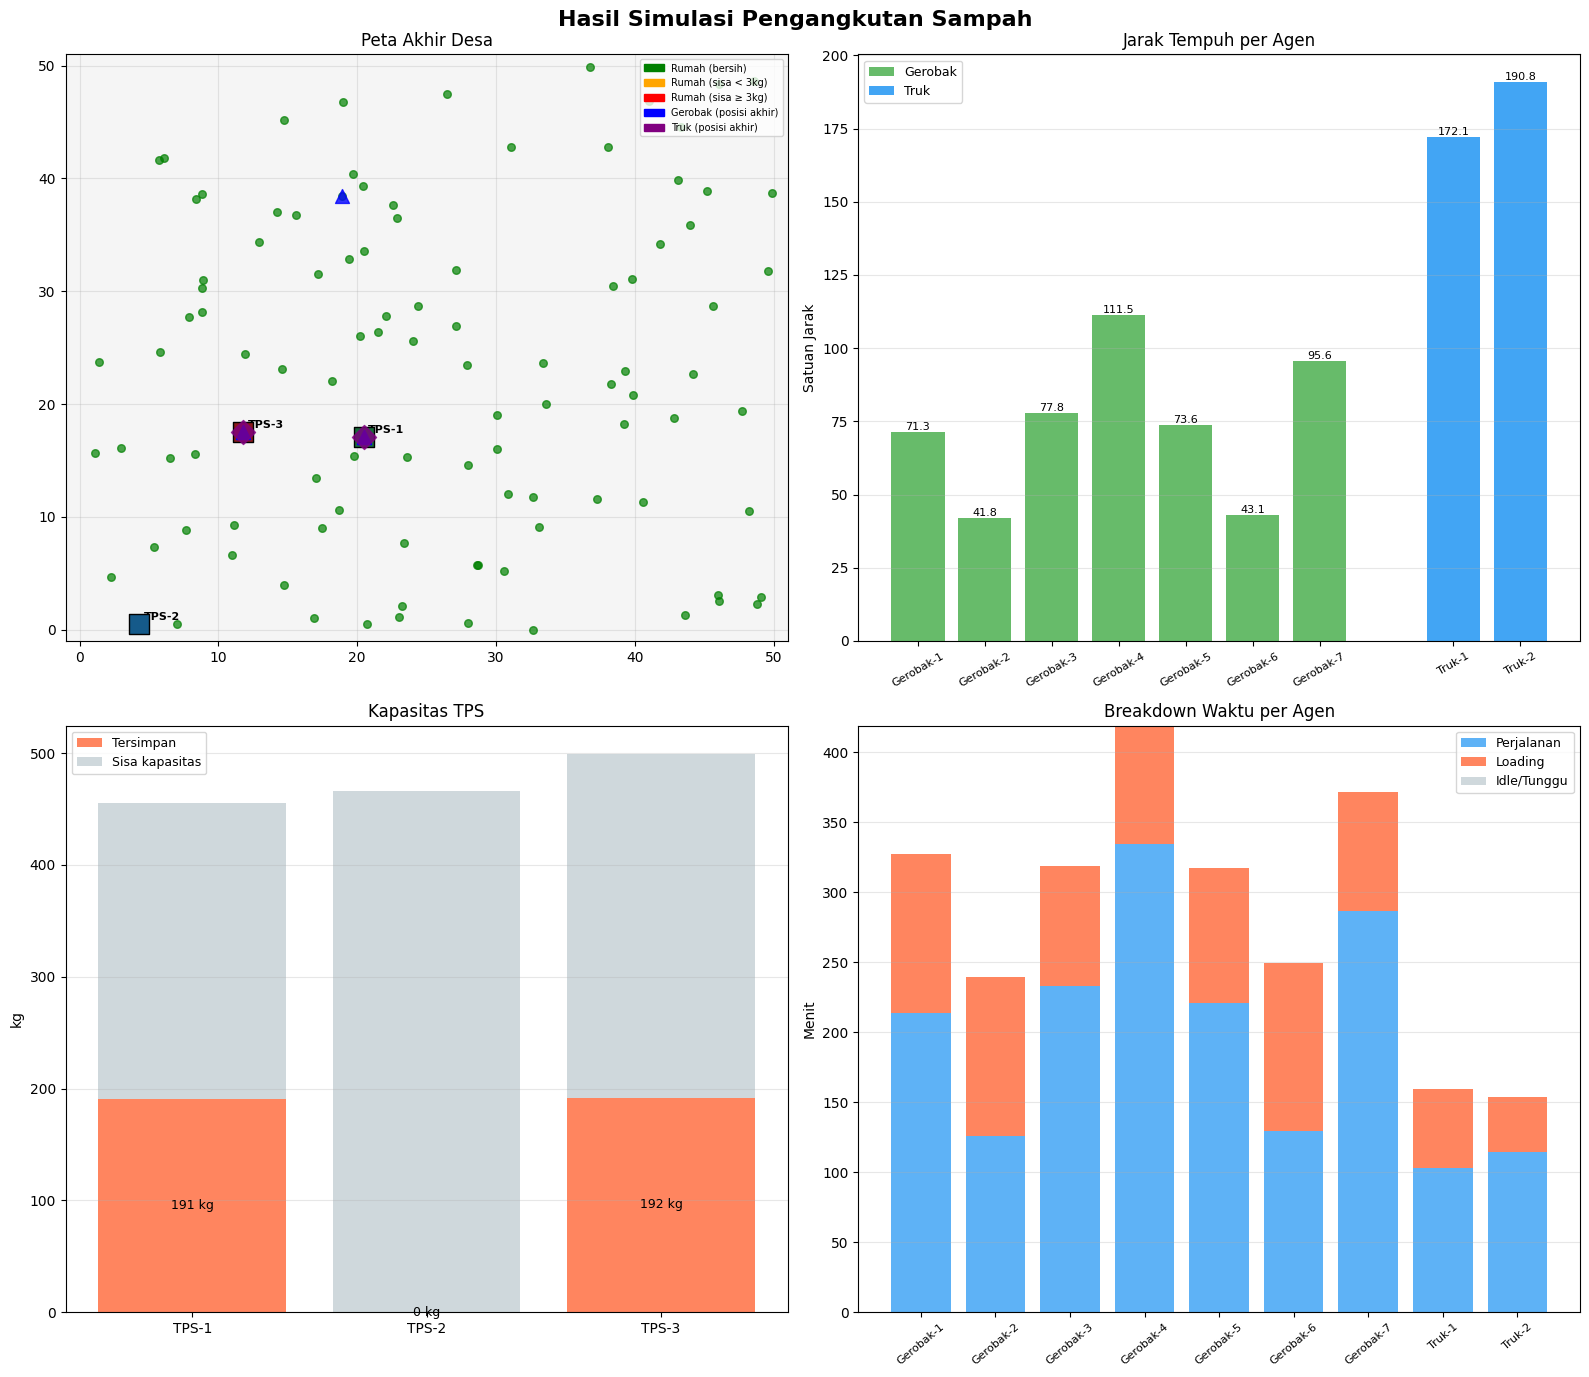

Grafik saved


In [128]:
# Cek konsistensi koordinat
vis_errors = []
for hid, (sx, sy) in _snapshot_houses.items():
    h = next(h for h in houses if h.id == hid)
    if abs(h.x - sx) > 1e-9 or abs(h.y - sy) > 1e-9:
        vis_errors.append(f"Rumah-{hid}: snapshot({sx},{sy}) != plot({h.x},{h.y})")
for tid, (sx, sy) in _snapshot_tps.items():
    t = next(t for t in tps_list if t.id == tid)
    if abs(t.x - sx) > 1e-9 or abs(t.y - sy) > 1e-9:
        vis_errors.append(f"TPS-{tid}: snapshot({sx},{sy}) != plot({t.x},{t.y})")
if vis_errors:
    print("Koordinat tidak konsisten")
    for e in vis_errors: print(f"{e}")
else:
    print("Koordinat konsisten")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Hasil Simulasi Pengangkutan Sampah', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Peta Akhir
ax = axes[0, 0]
ax.set_facecolor('#f5f5f5')
# Rumah: warna berdasarkan sisa sampah
for h in houses:
    color = 'green' if h.trash_remaining < 0.1 else ('orange' if h.trash_remaining < 3 else 'red')
    ax.scatter(h.x, h.y, c=color, s=30, alpha=0.7, zorder=2)
# TPS
tps_colors = ['#1a6b3c', '#155a8a', '#8b1a1a']
for i, tps in enumerate(tps_list):
    ax.scatter(tps.x, tps.y, c=tps_colors[i], s=200, marker='s', zorder=5, edgecolors='black')
    ax.annotate(f'TPS-{tps.id}', (tps.x, tps.y), xytext=(3,3), textcoords='offset points', fontsize=8, fontweight='bold')
# Posisi akhir gerobak & truk
for g in gerobak_list:
    ax.scatter(g.x, g.y, c='blue', s=100, marker='^', zorder=6, alpha=0.8)
for t in truk_list:
    ax.scatter(t.x, t.y, c='purple', s=150, marker='D', zorder=6, alpha=0.8)
legend_handles = [
    mpatches.Patch(color='green', label='Rumah (bersih)'),
    mpatches.Patch(color='orange', label='Rumah (sisa < 3kg)'),
    mpatches.Patch(color='red', label='Rumah (sisa ≥ 3kg)'),
    mpatches.Patch(color='blue', label='Gerobak (posisi akhir)'),
    mpatches.Patch(color='purple', label='Truk (posisi akhir)'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='upper right')
ax.set_title('Peta Akhir Desa')
ax.set_xlim(-1, GRID_SIZE+1); ax.set_ylim(-1, GRID_SIZE+1)
ax.grid(True, alpha=0.3)

# Plot 2: Jarak Tempuh
ax = axes[0, 1]
names_g = [g.name() for g in gerobak_list]
dists_g = [g.total_dist for g in gerobak_list]
names_t = [t.name() for t in truk_list]
dists_t = [t.total_dist for t in truk_list]
x_g = np.arange(len(names_g))
x_t = np.arange(len(names_t)) + len(names_g) + 1
bars_g = ax.bar(x_g, dists_g, color='#4CAF50', alpha=0.85, label='Gerobak')
bars_t = ax.bar(x_t, dists_t, color='#2196F3', alpha=0.85, label='Truk')
ax.bar_label(bars_g, fmt='%.1f', fontsize=8)
ax.bar_label(bars_t, fmt='%.1f', fontsize=8)
ax.set_xticks(list(x_g) + list(x_t))
ax.set_xticklabels(names_g + names_t, rotation=30, fontsize=8)
ax.set_title('Jarak Tempuh per Agen')
ax.set_ylabel('Satuan Jarak')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Status TPS
ax = axes[1, 0]
tps_names = [f'TPS-{t.id}' for t in tps_list]
stored    = [t.stored for t in tps_list]
available = [t.available for t in tps_list]
x = np.arange(len(tps_names))
b1 = ax.bar(x, stored, label='Tersimpan', color='#FF7043', alpha=0.85)
b2 = ax.bar(x, available, bottom=stored, label='Sisa kapasitas', color='#B0BEC5', alpha=0.6)
ax.bar_label(b1, fmt='%.0f kg', label_type='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tps_names, fontsize=10)
ax.set_title('Kapasitas TPS')
ax.set_ylabel('kg')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Breakdown Waktu
ax = axes[1, 1]
all_agents = gerobak_list + truk_list
agent_names = [a.name() for a in all_agents]
travel_times = [a.total_time_travel for a in all_agents]
load_times = [a.total_time_load for a in all_agents]
idle_times = [max(0,
    (min(int(a.time), GEROBAK_END if 'Gerobak' in a.name() else TRUK_END) -
        (GEROBAK_START if 'Gerobak' in a.name() else TRUK_START)) -
    a.total_time_travel - a.total_time_load
) for a in all_agents]
x = np.arange(len(agent_names))
b1 = ax.bar(x, travel_times, label='Perjalanan', color='#42A5F5', alpha=0.85)
b2 = ax.bar(x, load_times, bottom=travel_times, label='Loading', color='#FF7043', alpha=0.85)
b3 = ax.bar(x, idle_times, bottom=[travel_times[i]+load_times[i] for i in range(len(all_agents))], label='Idle/Tunggu', color='#B0BEC5', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(agent_names, rotation=40, fontsize=8)
ax.set_title('Breakdown Waktu per Agen')
ax.set_ylabel('Menit')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hasil_simulasi.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grafik saved")